In [2]:
# ==========================================
# Import Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from time import time

from sklearn.datasets import make_classification

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from scipy.stats import randint

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [3]:
# ==========================================
# Create Dataset
# ==========================================

X, y = make_classification(

    n_samples=1800,
    n_features=16,
    n_informative=10,
    n_redundant=4,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42

)

columns = [f"Feature_{i}" for i in range(1,17)]

df = pd.DataFrame(X, columns=columns)

df["Target"] = y

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Target
0,3.406055,3.234741,-2.161468,0.347898,1.739977,2.863508,-11.622001,-4.741654,0.415381,-2.366700,0.441202,7.366329,2.524137,-1.931214,0.131497,2.547326,2
1,1.347519,-0.730509,-0.542467,-0.427988,1.843313,0.972297,-6.017819,0.989812,1.405056,0.344261,-5.087875,3.937365,1.024931,1.351026,0.437177,-4.644779,2
2,-0.483159,1.799889,-1.046025,1.072383,3.554687,5.005367,-3.030833,-1.196035,1.480616,-1.489565,-1.301521,1.423677,0.800203,2.318192,0.626453,-6.531832,2
3,1.349067,1.967207,-2.165961,-1.330891,-0.691760,3.648330,-1.548731,-5.292290,10.772910,2.403330,0.834466,-3.817142,-6.428185,-3.462197,-0.192348,-0.188506,0
4,2.829853,4.339968,-1.560875,0.375781,2.277622,0.375450,-3.833180,-0.194912,-5.502477,-3.593677,-2.439048,3.614319,2.590705,2.700545,-2.179938,0.408940,2


In [4]:
# Dataset Shape

print("="*60)

print("Dataset Shape :",df.shape)

print("="*60)

display(df.head())

print("\n")

df.info()

print("\n")

display(df.describe().T)

Dataset Shape : (1800, 17)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Target
0,3.406055,3.234741,-2.161468,0.347898,1.739977,2.863508,-11.622001,-4.741654,0.415381,-2.366700,0.441202,7.366329,2.524137,-1.931214,0.131497,2.547326,2
1,1.347519,-0.730509,-0.542467,-0.427988,1.843313,0.972297,-6.017819,0.989812,1.405056,0.344261,-5.087875,3.937365,1.024931,1.351026,0.437177,-4.644779,2
2,-0.483159,1.799889,-1.046025,1.072383,3.554687,5.005367,-3.030833,-1.196035,1.480616,-1.489565,-1.301521,1.423677,0.800203,2.318192,0.626453,-6.531832,2
3,1.349067,1.967207,-2.165961,-1.330891,-0.691760,3.648330,-1.548731,-5.292290,10.772910,2.403330,0.834466,-3.817142,-6.428185,-3.462197,-0.192348,-0.188506,0
4,2.829853,4.339968,-1.560875,0.375781,2.277622,0.375450,-3.833180,-0.194912,-5.502477,-3.593677,-2.439048,3.614319,2.590705,2.700545,-2.179938,0.408940,2




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_1   1800 non-null   float64
 1   Feature_2   1800 non-null   float64
 2   Feature_3   1800 non-null   float64
 3   Feature_4   1800 non-null   float64
 4   Feature_5   1800 non-null   float64
 5   Feature_6   1800 non-null   float64
 6   Feature_7   1800 non-null   float64
 7   Feature_8   1800 non-null   float64
 8   Feature_9   1800 non-null   float64
 9   Feature_10  1800 non-null   float64
 10  Feature_11  1800 non-null   float64
 11  Feature_12  1800 non-null   float64
 12  Feature_13  1800 non-null   float64
 13  Feature_14  1800 non-null   float64
 14  Feature_15  1800 non-null   float64
 15  Feature_16  1800 non-null   float64
 16  Target      1800 non-null   int64  
dtypes: float64(16), int64(1)
memory usage: 239.2 KB




,count,mean,std,min,25%,50%,75%,max
Feature_1,1800.0,0.700511,2.669819,-7.749291,-1.175917,1.082446,2.688218,9.680148
Feature_2,1800.0,0.691512,2.838816,-8.247639,-1.222781,1.003264,2.725066,9.178984
Feature_3,1800.0,-0.680131,2.508071,-7.320542,-2.535008,-1.017518,1.240647,7.757816
Feature_4,1800.0,0.034707,0.989187,-3.264636,-0.645442,0.040638,0.705693,3.902799
Feature_5,1800.0,-0.674634,2.737475,-9.036399,-2.682103,-0.970106,1.073797,7.970720
Feature_6,1800.0,0.687800,2.589348,-8.522211,-1.219179,0.995327,2.632656,7.591456
Feature_7,1800.0,-0.929201,3.862062,-13.399062,-3.392083,-0.456571,1.985818,9.116569
Feature_8,1800.0,-0.733057,2.694758,-7.947959,-2.728431,-0.971294,1.273860,7.254671
Feature_9,1800.0,1.135459,4.536869,-9.285382,-2.133765,0.632988,3.936219,18.535243
Feature_10,1800.0,0.657009,2.761462,-7.721046,-1.304337,0.857424,2.620311,10.861926


Feature_1     0
Feature_2     0
Feature_3     0
Feature_4     0
Feature_5     0
Feature_6     0
Feature_7     0
Feature_8     0
Feature_9     0
Feature_10    0
Feature_11    0
Feature_12    0
Feature_13    0
Feature_14    0
Feature_15    0
Feature_16    0
Target        0
dtype: int64

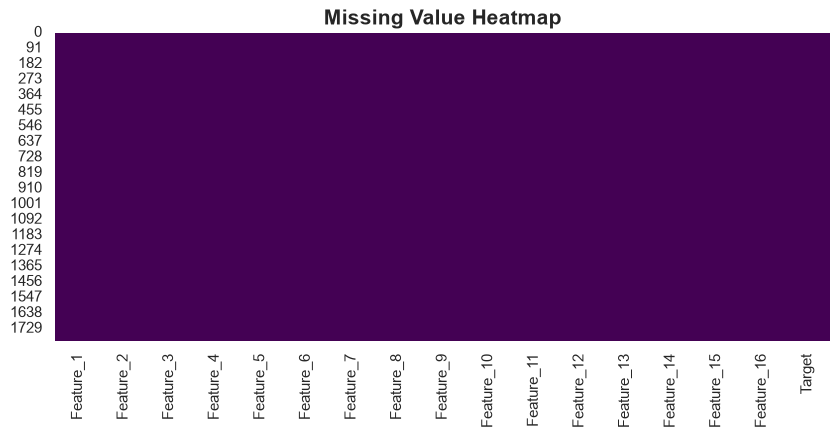

In [5]:
# ==========================================
# Missing Values
# ==========================================

missing = df.isnull().sum()

display(missing)

plt.figure(figsize=(10,4))

sns.heatmap(

    df.isnull(),

    cmap="viridis",

    cbar=False

)

plt.title(

    "Missing Value Heatmap",

    fontsize=15,

    fontweight="bold"

)

plt.show()

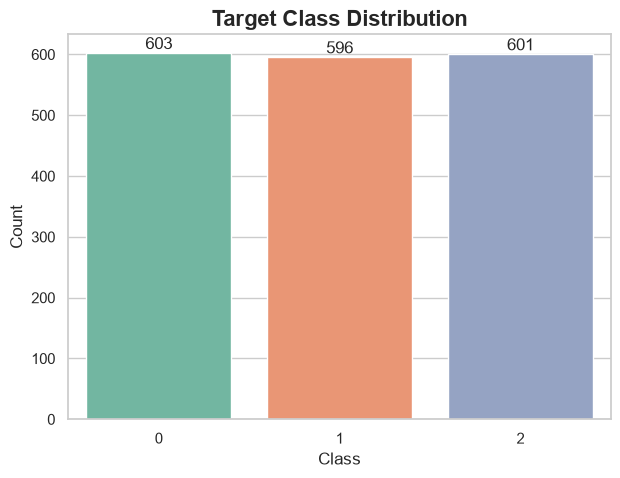

In [6]:
# ==========================================
# Class Distribution
# ==========================================

plt.figure(figsize=(7,5))

ax = sns.countplot(

    data=df,

    x="Target",

    palette="Set2"

)

for container in ax.containers:

    ax.bar_label(container)

plt.title(

    "Target Class Distribution",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

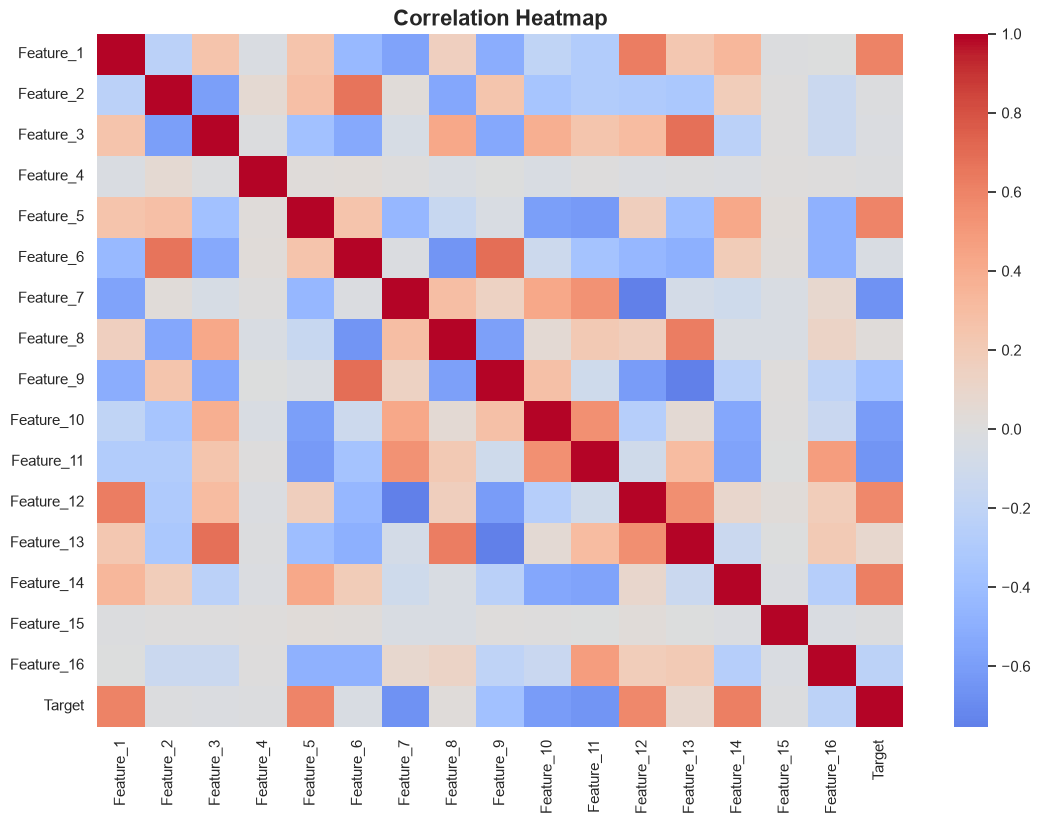

In [7]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(13,9))

sns.heatmap(

    df.corr(),

    cmap="coolwarm",

    center=0

)

plt.title(

    "Correlation Heatmap",

    fontsize=16,

    fontweight="bold"

)

plt.show()

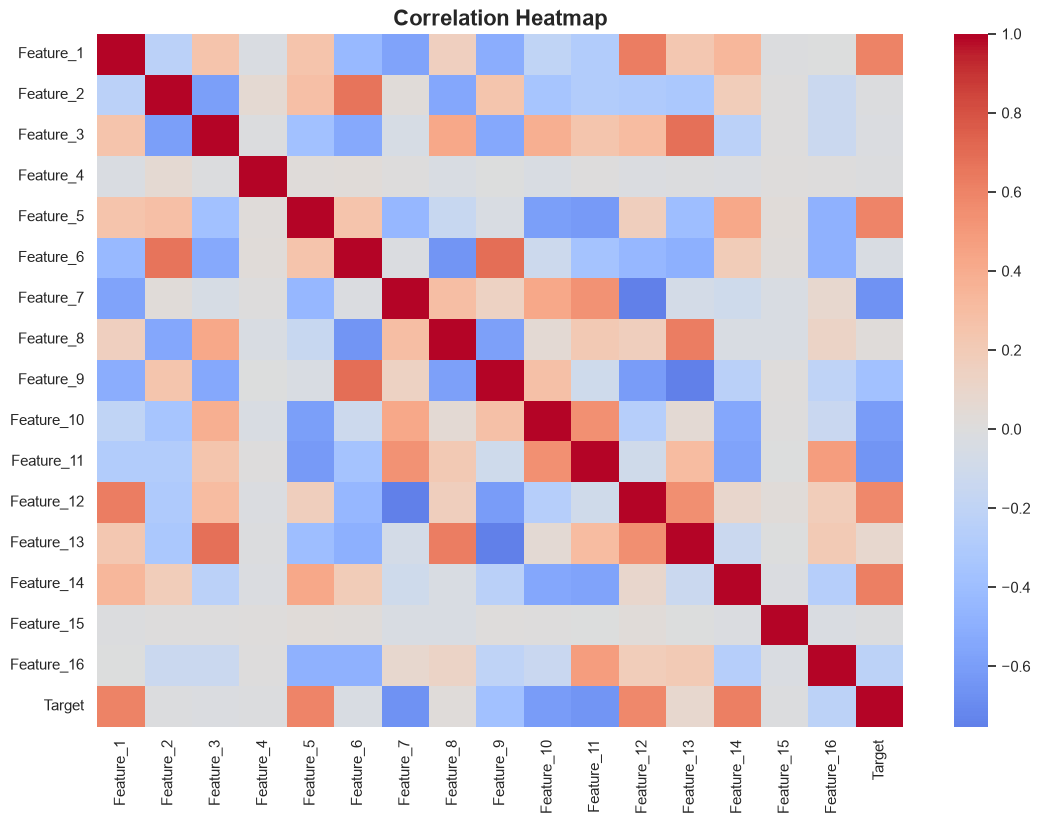

In [8]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(13,9))

sns.heatmap(

    df.corr(),

    cmap="coolwarm",

    center=0

)

plt.title(

    "Correlation Heatmap",

    fontsize=16,

    fontweight="bold"

)

plt.show()

In [9]:
# ==========================================
# Train Test Split
# ==========================================

X = df.drop("Target",axis=1)

y = df["Target"]

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Shape :",X_train.shape)

print("Testing Shape :",X_test.shape)

Training Shape : (1440, 16)
Testing Shape : (360, 16)


In [10]:
# ==========================================
# Default Random Forest
# ==========================================

rf_start = time()

rf_default = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    oob_score=True,

    n_jobs=-1

)

rf_default.fit(X_train,y_train)

rf_time = time() - rf_start

default_prediction = rf_default.predict(X_test)

default_accuracy = accuracy_score(

    y_test,

    default_prediction

)

print("="*60)

print("Default Random Forest")

print("="*60)

print(f"Accuracy      : {default_accuracy:.4f}")

print(f"OOB Score     : {rf_default.oob_score_:.4f}")

print(f"Training Time : {rf_time:.3f} Seconds")

Default Random Forest
Accuracy      : 0.9944
OOB Score     : 0.9896
Training Time : 0.425 Seconds


In [11]:
# ==========================================
# Hyperparameter Grid
# ==========================================

param_grid = {

    "n_estimators":[100,200],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2],

    "max_features":["sqrt","log2"]

}

pd.DataFrame({

    "Parameter":list(param_grid.keys()),

    "Values":[str(v) for v in param_grid.values()]

})

,Parameter,Values
0,n_estimators,"[100, 200]"
1,max_depth,"[5, 10, None]"
2,min_samples_split,"[2, 5]"
3,min_samples_leaf,"[1, 2]"
4,max_features,"['sqrt', 'log2']"


In [12]:
# ==========================================
# GridSearchCV
# ==========================================

grid_start = time()

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(

        random_state=42,

        oob_score=True,

        n_jobs=-1

    ),

    param_grid=param_grid,

    scoring="accuracy",

    cv=5,

    n_jobs=-1

)

grid_search.fit(X_train,y_train)

grid_time = time()-grid_start

best_grid = grid_search.best_estimator_

grid_prediction = best_grid.predict(X_test)

grid_accuracy = accuracy_score(

    y_test,

    grid_prediction

)

print("="*60)

print("GridSearchCV Completed")

print("="*60)

print("Best Parameters")

print(grid_search.best_params_)

print("\nAccuracy :",round(grid_accuracy,4))

print("OOB Score :",round(best_grid.oob_score_,4))

print("Training Time :",round(grid_time,2),"Seconds")

GridSearchCV Completed
Best Parameters
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Accuracy : 0.9944
OOB Score : 0.9903
Training Time : 105.38 Seconds


In [13]:
# ==========================================
# RandomizedSearchCV
# ==========================================

random_params = {

    "n_estimators": randint(100, 400),

    "max_depth": [5, 10, 15, 20, None],

    "min_samples_split": randint(2, 10),

    "min_samples_leaf": randint(1, 5),

    "max_features": ["sqrt", "log2"]

}

random_start = time()

random_search = RandomizedSearchCV(

    estimator=RandomForestClassifier(

        random_state=42,

        oob_score=True,

        n_jobs=-1

    ),

    param_distributions=random_params,

    n_iter=20,

    scoring="accuracy",

    cv=5,

    random_state=42,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

random_time = time() - random_start

best_random = random_search.best_estimator_

random_prediction = best_random.predict(X_test)

random_accuracy = accuracy_score(

    y_test,

    random_prediction

)

print("="*60)

print("RandomizedSearchCV Completed")

print("="*60)

print("Best Parameters")

print(random_search.best_params_)

print("\nAccuracy :", round(random_accuracy, 4))

print("OOB Score :", round(best_random.oob_score_, 4))

print("Training Time :", round(random_time, 2), "Seconds")

RandomizedSearchCV Completed
Best Parameters
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 363}

Accuracy : 0.9944
OOB Score : 0.9889
Training Time : 69.85 Seconds


In [14]:
# ==========================================
# Final Model Comparison
# ==========================================

comparison = pd.DataFrame({

    "Model": [

        "Default Random Forest",

        "GridSearchCV",

        "RandomizedSearchCV"

    ],

    "Test Accuracy": [

        default_accuracy,

        grid_accuracy,

        random_accuracy

    ],

    "OOB Score": [

        rf_default.oob_score_,

        best_grid.oob_score_,

        best_random.oob_score_

    ],

    "Training Time (sec)": [

        rf_time,

        grid_time,

        random_time

    ]

})

comparison = comparison.round(4)

display(comparison)

,Model,Test Accuracy,OOB Score,Training Time (sec)
0,Default Random Forest,0.9944,0.9896,0.4245
1,GridSearchCV,0.9944,0.9903,105.3802
2,RandomizedSearchCV,0.9944,0.9889,69.8544


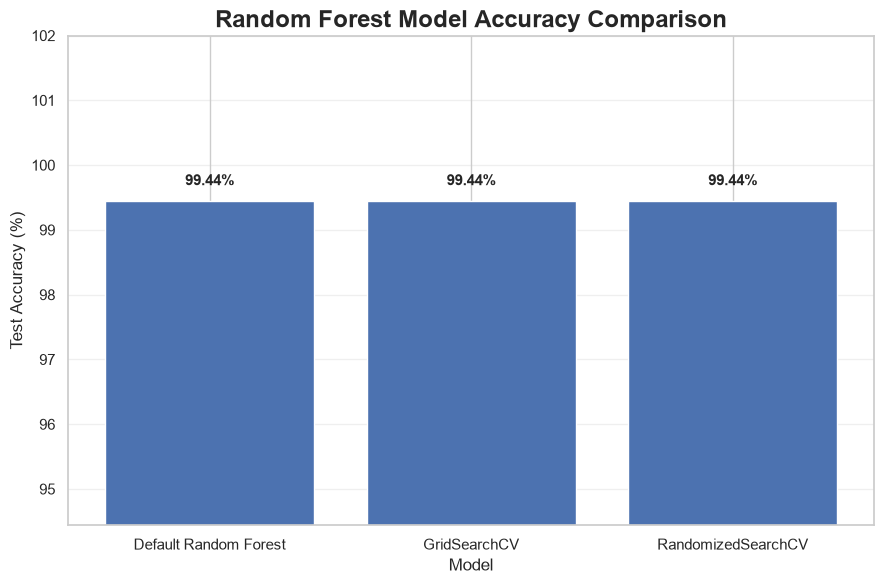

In [15]:
# ==========================================
# Accuracy Comparison
# ==========================================

plt.figure(figsize=(9, 6))

bars = plt.bar(

    comparison["Model"],

    comparison["Test Accuracy"] * 100

)

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width() / 2,

        height + 0.2,

        f"{height:.2f}%",

        ha="center",

        va="bottom",

        fontsize=11,

        fontweight="bold"

    )

plt.title(

    "Random Forest Model Accuracy Comparison",

    fontsize=17,

    fontweight="bold"

)

plt.xlabel("Model")

plt.ylabel("Test Accuracy (%)")

plt.ylim(

    max(0, comparison["Test Accuracy"].min() * 100 - 5),

    102

)

plt.grid(

    axis="y",

    alpha=0.3

)

plt.tight_layout()

plt.show()


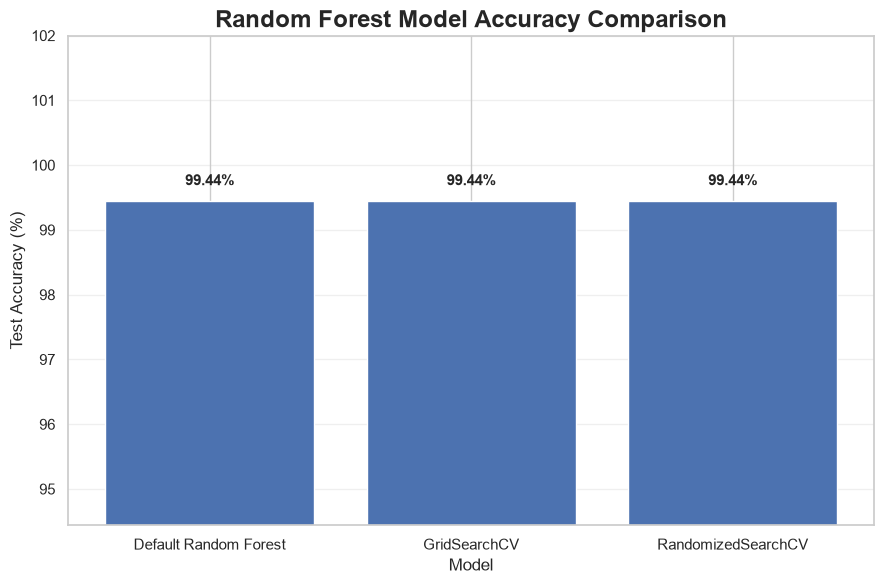

In [16]:
# ==========================================
# Accuracy Comparison
# ==========================================

plt.figure(figsize=(9, 6))

bars = plt.bar(

    comparison["Model"],

    comparison["Test Accuracy"] * 100

)

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width() / 2,

        height + 0.2,

        f"{height:.2f}%",

        ha="center",

        va="bottom",

        fontsize=11,

        fontweight="bold"

    )

plt.title(

    "Random Forest Model Accuracy Comparison",

    fontsize=17,

    fontweight="bold"

)

plt.xlabel("Model")

plt.ylabel("Test Accuracy (%)")

plt.ylim(

    max(0, comparison["Test Accuracy"].min() * 100 - 5),

    102

)

plt.grid(

    axis="y",

    alpha=0.3

)

plt.tight_layout()

plt.show()

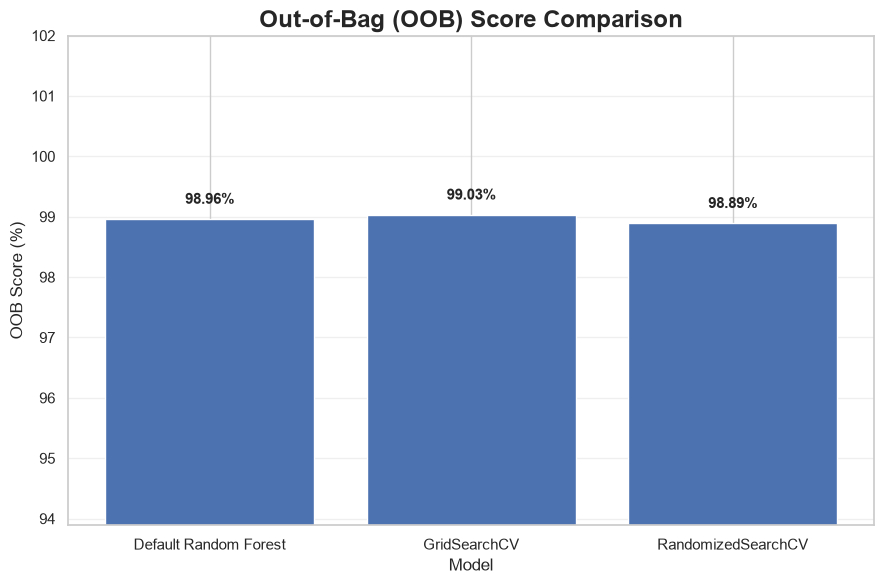

In [17]:
# ==========================================
# OOB Score Comparison
# ==========================================

plt.figure(figsize=(9, 6))

bars = plt.bar(

    comparison["Model"],

    comparison["OOB Score"] * 100

)

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width() / 2,

        height + 0.2,

        f"{height:.2f}%",

        ha="center",

        va="bottom",

        fontsize=11,

        fontweight="bold"

    )

plt.title(

    "Out-of-Bag (OOB) Score Comparison",

    fontsize=17,

    fontweight="bold"

)

plt.xlabel("Model")

plt.ylabel("OOB Score (%)")

plt.ylim(

    max(0, comparison["OOB Score"].min() * 100 - 5),

    102

)

plt.grid(

    axis="y",

    alpha=0.3

)

plt.tight_layout()

plt.show()

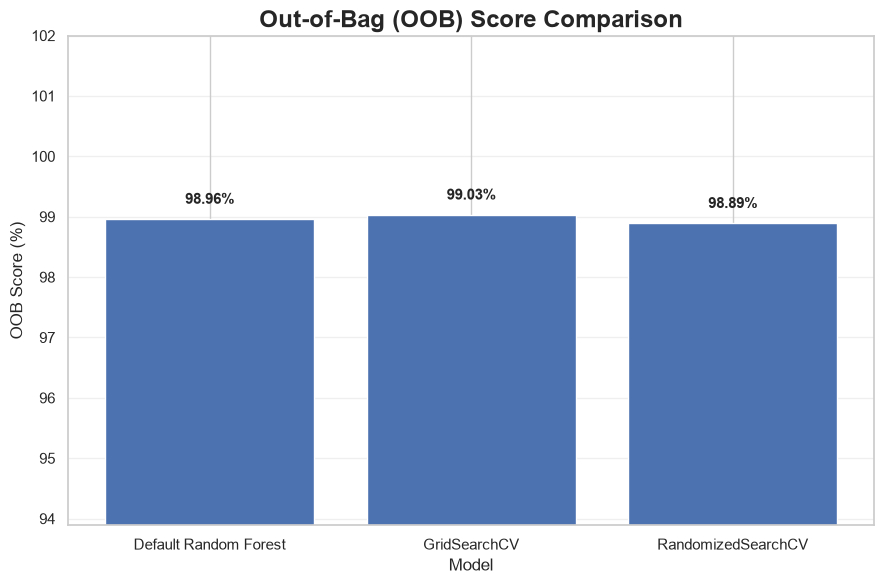

In [18]:
# ==========================================
# OOB Score Comparison
# ==========================================

plt.figure(figsize=(9, 6))

bars = plt.bar(

    comparison["Model"],

    comparison["OOB Score"] * 100

)

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width() / 2,

        height + 0.2,

        f"{height:.2f}%",

        ha="center",

        va="bottom",

        fontsize=11,

        fontweight="bold"

    )

plt.title(

    "Out-of-Bag (OOB) Score Comparison",

    fontsize=17,

    fontweight="bold"

)

plt.xlabel("Model")

plt.ylabel("OOB Score (%)")

plt.ylim(

    max(0, comparison["OOB Score"].min() * 100 - 5),

    102

)

plt.grid(

    axis="y",

    alpha=0.3

)

plt.tight_layout()

plt.show()

,Feature,Importance
0,Feature_11,0.139623
1,Feature_3,0.119865
2,Feature_14,0.105126
3,Feature_6,0.103671
4,Feature_8,0.082670
5,Feature_1,0.073555
6,Feature_12,0.064559
7,Feature_7,0.055196
8,Feature_2,0.054499
9,Feature_5,0.053883


In [20]:
# ==========================================
# Select Best Model
# ==========================================

best_model_name = comparison.loc[

    comparison["Test Accuracy"].idxmax(),

    "Model"

]

best_accuracy = comparison["Test Accuracy"].max()

print("=" * 60)

print("BEST MODEL")

print("=" * 60)

print(f"Model    : {best_model_name}")

print(f"Accuracy : {best_accuracy * 100:.2f}%")

print("=" * 60)

BEST MODEL
Model    : Default Random Forest
Accuracy : 99.44%


In [21]:
# ==========================================
# Best Hyperparameters
# ==========================================

print("=" * 60)

print("BEST GRIDSEARCHCV PARAMETERS")

print("=" * 60)

for parameter, value in grid_search.best_params_.items():

    print(f"{parameter}: {value}")


print("\n")

print("=" * 60)

print("BEST RANDOMIZEDSEARCHCV PARAMETERS")

print("=" * 60)

for parameter, value in random_search.best_params_.items():

    print(f"{parameter}: {value}")

print("=" * 60)

BEST GRIDSEARCHCV PARAMETERS
max_depth: 10
max_features: sqrt
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 200


BEST RANDOMIZEDSEARCHCV PARAMETERS
max_depth: 10
max_features: log2
min_samples_leaf: 4
min_samples_split: 8
n_estimators: 363
